In [1]:
print('netflix eda')

netflix eda


# Netflix Movies and TV Shows - Exploratory Data Analysis

**Internship:** CodeAlpha

**Task:** Exploratory Data Analysis (EDA)

**Prepared by:** Devika Madhavankutty

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 1: Import Required Libraries

In this step, we import the Python libraries required for data analysis and visualization.

In [3]:
plt.style.use("ggplot")
%matplotlib inline

In [7]:
##load the dataset

df=pd.read_csv("../dataset/netflix_titles.csv")

In [9]:
## Step 3: Display the First three Rows
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [12]:
## Step 4: Find the Shape of the Dataset to  check how many rows and columns

df.shape


(8807, 12)

In [13]:
##also checking columns
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

In [15]:
##get information about the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [16]:
##counts the missing values

df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [17]:
#checking duplicate rows

df.duplicated().sum()

np.int64(0)

In [18]:
#show statistics for numerical columns
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


# Exploratory Questions

In this project, we will answer the following questions:

1. How many Movies and TV Shows are available on Netflix?
2. Which countries have produced the most Netflix content?
3. What are the top 10 genres on Netflix?
4. Which ratings are most common?
5. How has Netflix content changed over the years?

In [20]:
## Question 1: How many Movies and TV Shows are available on Netflix?

df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

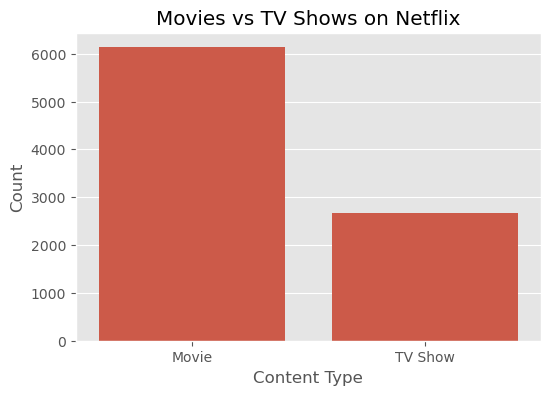

In [21]:
## A bar chart containing no of rows and tv shows

plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Count")

plt.show()

In [22]:
## Question 2: Which countries have the highest number of Netflix titles?

df["country"].value_counts().head(10)

country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

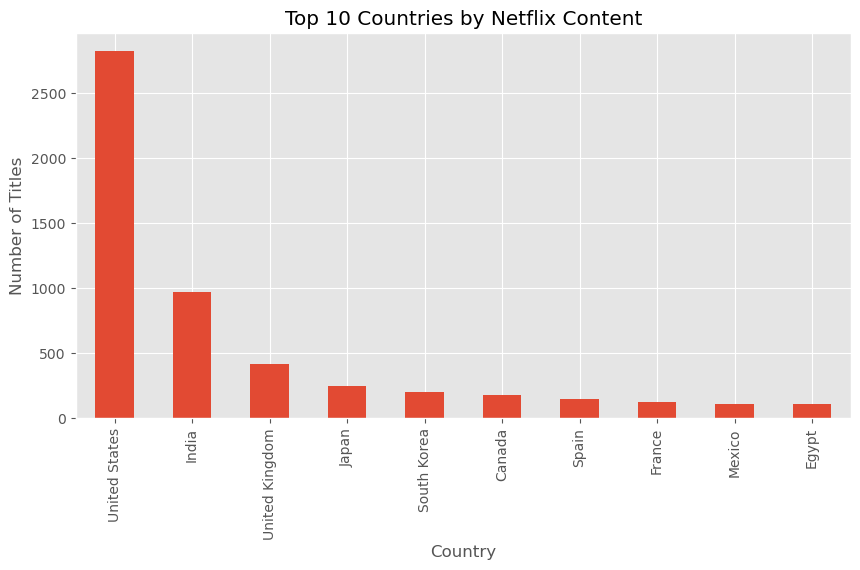

In [24]:
plt.figure(figsize=(10,5))

df["country"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.show()

##united states has more no of netflix contents

In [27]:
## Question 3: What are the most popular genres on Netflix?

df["listed_in"].value_counts().head(10)


listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64

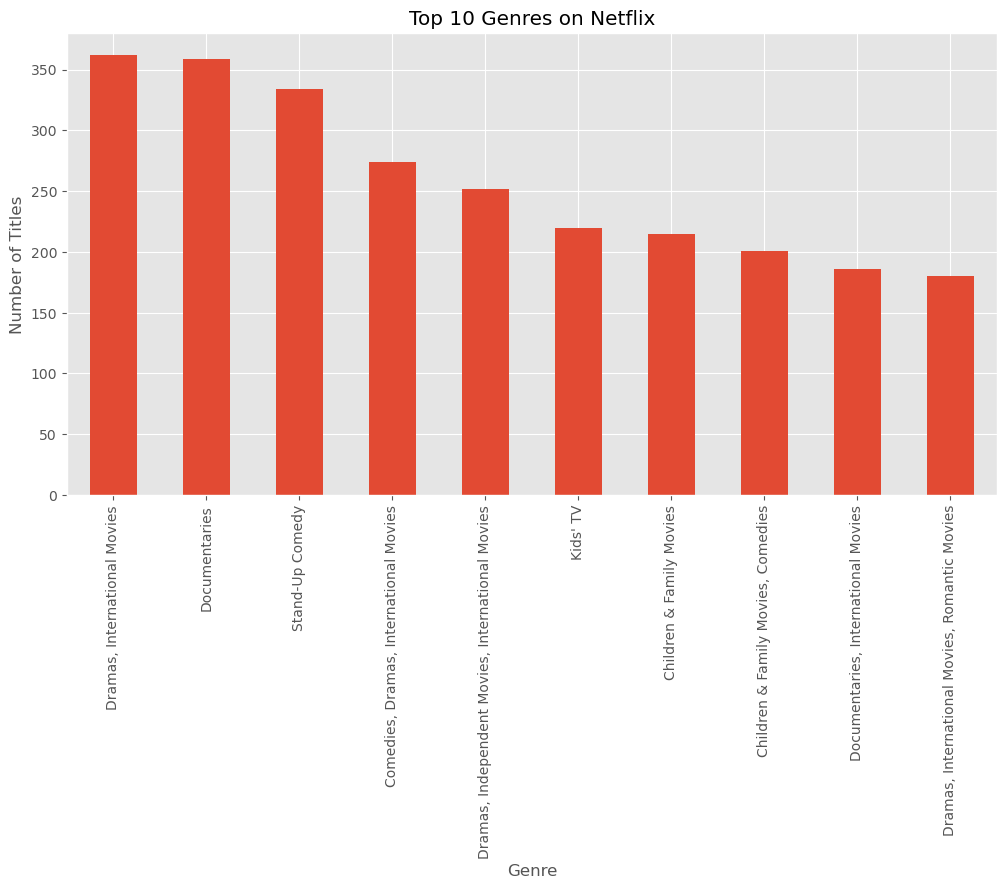

In [30]:
plt.figure(figsize=(12,6))

df["listed_in"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.show()

In [31]:
##Which ratings are most common?

df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

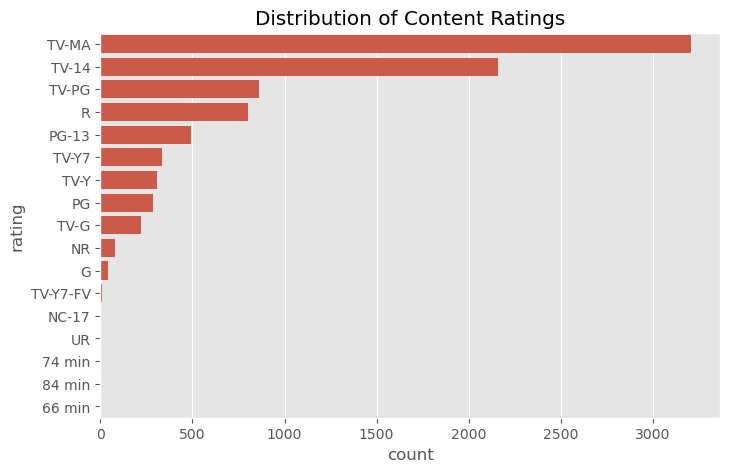

In [32]:
plt.figure(figsize=(8,5))

sns.countplot(y="rating", data=df, order=df["rating"].value_counts().index)

plt.title("Distribution of Content Ratings")

plt.show()

In [33]:
##Which release years have the most titles?

top_years = df["release_year"].value_counts().head(10)

top_years


release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

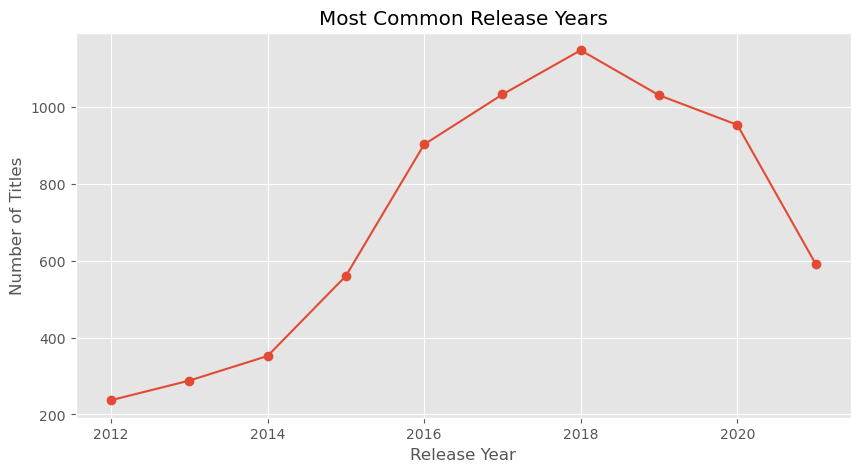

In [34]:
plt.figure(figsize=(10,5))

top_years.sort_index().plot(kind="line", marker="o")

plt.title("Most Common Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

# Final Conclusion

In this project, the Netflix dataset was explored using Python and Pandas. The dataset was examined for its structure, missing values, duplicate records, and statistical summary. Several business questions were answered using visualizations.

Key findings:
- Netflix contains more Movies than TV Shows.
- The United States contributes the highest number of titles.
- Drama and International Movies are among the most common genres.
- TV-MA is one of the most frequent content ratings.
- Netflix offers content released across many years, showing a diverse library.

This exploratory analysis provides useful insights into Netflix's content collection and demonstrates the importance of data exploration before advanced analysis.